In [1]:
from pathlib import Path
import os
import subprocess
import sys

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.tools import tool

load_dotenv()


True

In [2]:
@tool
def read_file(file_path: str) -> str:
    """
    Read the contents of a file in the project.

    Use this when you need to inspect source code, configuration,
    requirements, notebooks, or other project files.
    """
    path = Path(file_path)
    if not path.exists():
        return f"File not found: {file_path}"
    if not path.is_file():
        return f"Path is not a file: {file_path}"
    try:
        return path.read_text(encoding="utf-8")
    except UnicodeDecodeError:
        return f"Could not read {file_path}: file is not UTF-8 text."
    except Exception as e:
        return f"Error reading {file_path}: {type(e).__name__}: {e}"


In [4]:
read_file.invoke("../web_github_agent/node.py")


'from typing import TypedDict, Annotated\n\nfrom langgraph.graph import add_messages\n\nfrom web_github_agent.agent import research_agent\nfrom web_github_agent.tools import research_tools\n\nclass ResearchState(TypedDict):\n    messages: Annotated[list,add_messages]\n\n# Research Node\n\ndef research_node(state):\n    query = state["messages"][-1].content\n    response = research_agent(query)\n    return {"messages": [response]}'

In [5]:
@tool
def list_files(directory: str = ".") -> str:
    """
    List files and directories inside a project directory.

    Use this to understand the project structure before inspecting files.
    """

    path = Path(directory)

    if not path.exists():
        return f"Directory not found: {directory}"

    if not path.is_dir():
        return f"Path is not a directory: {directory}"

    try:
        items = []

        for item in sorted(path.iterdir()):
            if item.name.startswith("."):
                continue

            if item.is_dir():
                items.append(f"[DIR]  {item.name}/")
            else:
                items.append(f"[FILE] {item.name}")

        if not items:
            return f"{directory} is empty."

        return "\n".join(items)

    except Exception as e:
        return f"Error listing directory: {type(e).__name__}: {e}"


In [24]:
@tool
def search_code(
    search_term: str,
    directory: str = "."
) -> str:
    """
    Search for a text string across source code files in a project.

    Use this to find where a function, class, variable, import,
    error message, or package name is used.
    """

    root = Path(directory)

    if not root.exists():
        return f"Directory not found: {directory}"

    if not root.is_dir():
        return f"Path is not a directory: {directory}"

    ignored_dirs = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        "node_modules",
        ".ipynb_checkpoints",
    }

    extensions = {
        ".py",
        ".js",
        ".ts",
        ".tsx",
        ".jsx",
        ".json",
        ".yaml",
        ".yml",
        ".toml",
        ".txt",
        ".md",
    }

    matches = []

    try:
        for path in root.rglob("*"):

            if not path.is_file():
                continue

            if any(part in ignored_dirs for part in path.parts):
                continue

            if path.suffix.lower() not in extensions:
                continue

            try:
                lines = path.read_text(
                    encoding="utf-8",
                    errors="ignore"
                ).splitlines()

                for line_number, line in enumerate(lines, start=1):

                    if search_term.lower() in line.lower():

                        matches.append(
                            f"{path}:{line_number}: {line.strip()}"
                        )

            except Exception:
                continue

        if not matches:
            return f"No matches found for: {search_term}"

        # Prevent huge tool responses
        max_results = 50

        result = "\n".join(matches[:max_results])

        if len(matches) > max_results:
            result += (
                f"\n\n... {len(matches) - max_results} "
                "additional matches omitted."
            )

        return result

    except Exception as e:
        return f"Search error: {type(e).__name__}: {e}"


In [26]:
print(search_code.invoke("Tavily"))

No matches found for: Tavily


In [12]:
@tool
def installed_packages() -> str:
    """
    Show Python packages installed in the current Python environment.

    Use this to diagnose missing packages, dependency issues,
    and package-version problems.
    """

    try:
        result = subprocess.run(
            [
                sys.executable,
                "-m",
                "pip",
                "list",
                "--format=columns"
            ],
            capture_output=True,
            text=True,
            timeout=30,
        )

        if result.returncode != 0:
            return (
                "Could not retrieve installed packages.\n"
                f"STDERR:\n{result.stderr}"
            )

        return (
            f"Python executable: {sys.executable}\n\n"
            f"{result.stdout}"
        )

    except subprocess.TimeoutExpired:
        return "Timed out while retrieving installed packages."

    except Exception as e:
        return f"Error: {type(e).__name__}: {e}"


In [13]:
print(installed_packages.invoke({}))

Python executable: /Users/raghuvar/Desktop/vsc/final-rag-project/venv/bin/python

Package                                  Version
---------------------------------------- -----------
aiohappyeyeballs                         2.7.1
aiohttp                                  3.14.3
aiosignal                                1.4.0
annotated-doc                            0.0.5
annotated-types                          0.8.0
anyio                                    4.14.2
appnope                                  1.0.0
asttokens                                3.0.2
attrs                                    26.1.0
bcrypt                                   5.0.0
beautifulsoup4                           4.15.0
build                                    1.6.0
certifi                                  2026.7.22
charset-normalizer                       3.5.1
chromadb                                 1.5.9
click                                    8.5.0
comm                                     0.2.3
debugpy  

In [14]:
from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

@tool
def web_search(query: str) -> str:
    """
    Search the web for technical documentation, error messages,
    package issues, GitHub discussions, and troubleshooting information.

    Use this when local project inspection is insufficient.
    """

    try:
        results = tavily.invoke(query)

        return str(results)

    except Exception as e:
        return f"Web search error: {type(e).__name__}: {e}"



/var/folders/t8/9stv2ccn0m9dn8s7nvjnyqwm0000gn/T/ipykernel_7880/1246999127.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults
/var/folders/t8/9stv2ccn0m9dn8s7nvjnyqwm0000gn/T/ipykernel_7880/1246999127.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


In [15]:
result = web_search.invoke(
    "LangGraph ToolNode tools_condition documentation"
)

print(result)


[{'title': 'ToolNode — LangGraph Agents', 'url': 'https://braindrip.blog/courses/langgraph-agents/02-tools-and-models/tool-node', 'content': 'tools_condition is a routing function that inspects the last AI message: If If no tool calls exist (the model responded with text), it routes to END .', 'score': 0.8660535}, {'title': 'langgraph/libs/prebuilt/langgraph/prebuilt/tool_node.py at main · langchain-ai/langgraph · GitHub', 'url': 'https://github.com/langchain-ai/langgraph/blob/main/libs/prebuilt/langgraph/prebuilt/tool_node.py', 'content': '- [`ToolRuntime`][langgraph.prebuilt.ToolRuntime]: Runtime information for tools, bundling together `state`, `context`,\n\n`config`, `stream\\_writer`, `tool\\_call\\_id`, and `store`\n\n- [`tools\\_condition`][langgraph.prebuilt.tools\\_condition]: Utility function for conditional routing based on tool calls\n\nTypical Usage:\n\n```python\n\nfrom langchain\\_core.tools import tool\n\nfrom langchain.tools import ToolNode\n\n@tool\n\ndef my\\_tool(x:

In [16]:
debug_tools = [
    read_file,
    list_files,
    search_code,
    installed_packages,
    web_search,
]


In [17]:
llm = init_chat_model(
    model_provider="groq",
    model="openai/gpt-oss-120b"
)

llm_with_tools = llm.bind_tools(debug_tools)


In [18]:
SYSTEM_PROMPT = """
You are a software debugging agent.

Your job is to diagnose software problems using the tools available to you.

Follow this general strategy:

1. Understand the reported error or problem.
2. Inspect the project structure when necessary.
3. Read relevant source files.
4. Search the codebase for relevant symbols, imports, functions,
   variables, and error messages.
5. Inspect installed Python packages when dependency issues are possible.
6. Use web search when local investigation is insufficient.
7. Form a specific hypothesis about the root cause.
8. If possible, verify the hypothesis using additional tool calls.
9. Give a concise final diagnosis and recommended fix.

Do not immediately recommend installing packages or changing code.
First investigate the actual project and environment.

When you use web search, prefer official documentation and
reliable technical sources.
"""


In [19]:
from typing import TypedDict, Annotated
from langgraph.graph import add_messages


class DebugState(TypedDict):
    messages: Annotated[list, add_messages]


In [20]:
from langchain_core.messages import SystemMessage

def debug_node(state: DebugState):
    messages = [
        SystemMessage(content=SYSTEM_PROMPT),
        *state["messages"],
    ]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


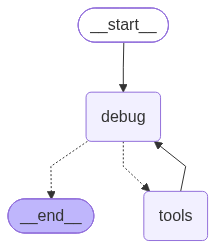

In [21]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END

graph = StateGraph(DebugState)

graph.add_node("debug", debug_node)
graph.add_node("tools", ToolNode(debug_tools))

graph.add_edge(START, "debug")
graph.add_conditional_edges(
    "debug",
    tools_condition
)

graph.add_edge("tools", "debug")

builder = graph.compile()
builder


In [22]:
result = builder.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": """
I am getting this error when running my project:

ModuleNotFoundError: No module named 'web_github_agent'

I am running the command:

python graph.py

My project looks like this:

final-rag-project/
    web_github_agent/
        __init__.py
        graph.py
        node.py
        tools.py

What is causing the problem and how should I fix it?
"""
            }
        ]
    }
)


In [23]:
for message in result["messages"]:

    print("\n==============================")

    print("Type:", type(message).__name__)

    print("Content:", message.content)

    if hasattr(message, "tool_calls"):
        print("Tool calls:", message.tool_calls)



Type: HumanMessage
Content: 
I am getting this error when running my project:

ModuleNotFoundError: No module named 'web_github_agent'

I am running the command:

python graph.py

My project looks like this:

final-rag-project/
    web_github_agent/
        __init__.py
        graph.py
        node.py
        tools.py

What is causing the problem and how should I fix it?


Type: AIMessage
Content: **What’s happening**

Your source tree is a proper Python *package*:

```
final‑rag‑project/
│
└─ web_github_agent/
   ├─ __init__.py
   ├─ graph.py
   ├─ node.py
   └─ tools.py
```

When you run

```bash
python graph.py
```

you are executing the file **as a script**, not as a module that belongs to the `web_github_agent` package.  
During script execution Python sets `sys.path[0]` to the directory that contains the script (the `web_github_agent` folder). Consequently the package name `web_github_agent` is **not** on the import search path, so any line in `graph.py` such as

```python
from 